# Goodwill Impairment — can a bloated balance sheet warn you before the write-down? 🧾
### When a company overpays for a takeover, the bill shows up later. Can you see it coming?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

When one company buys another for **more than the target's assets are worth**, the extra money it paid gets parked on the balance sheet under a line called **goodwill**. It just sits there — until an accountant decides the acquisition isn't worth what was paid, and forces a **write-down** (an *impairment*). That write-down is an admission: *we overpaid.*

The idea we're testing: a firm carrying a **big pile of goodwill** relative to its assets is a firm that probably overpaid — so it should (a) be **more likely to write it down** later, and (b) see its **stock underperform** as that bad news leaks out. In short: can a bloated goodwill balance predict the write-down *and* the drop, before they happen?

> ⚠️ **Big caveat, stated up front.** To test this on *real* companies you'd need point-in-time goodwill figures and tagged write-down events for thousands of firms — data a free retail stack simply can't reach. So this study runs on a **synthetic (made-up but rule-governed) world** where we *know* the answer, to check whether the method works. It can't earn a `REAL` stamp — only a `WEAK` one.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from goodwill_impairment import data, strategy as st

# Synthetic-only study: the headline world is deterministic and offline. There is NO real tape.
PANEL, TRUTH = data.synthetic_panel(ret_alpha=-0.14, imp_beta=2.2, seed=570)
HAVE_REAL = False   # a point-in-time goodwill/impairment panel is not reachable (see data.py)
print("synthetic goodwill panel:", len(PANEL), "firms | panel fp",
      data.fingerprint(PANEL), "| real tape present:", HAVE_REAL)


synthetic goodwill panel: 400 firms | panel fp 6bd491ebb228 | real tape present: False


## The answer first 🎯

| Question | Answer |
|---|---|
| Does high goodwill predict the write-down? | **Yes, in the model** — the most goodwill-heavy firms impaired at **12.5%** vs **6.2%** for the lean ones. |
| Does high goodwill predict the *drop*? | **Yes, in the model** — the lean-goodwill firms beat the bloated ones by **+5.78%** over the forward window. |
| Is it just luck? | **No** — a shuffle test puts the odds at *p* = 0.0005. The effect the model planted is cleanly recovered. |
| So can you trade it? | **Not from here.** There's no real data to test it on, so this is a *method demo*, not a live signal. |

> The engine works — it catches the effect when it's really there and stays silent when it isn't. But *catching a planted effect in a simulation* is not the same as *finding it on the real market*. For that you'd need accounting data we can't get for free.

## 1 · The claim

> *"A high goodwill-to-assets ratio flags an overpaid acquisition; that overpayment later surfaces as a write-down, and high-goodwill firms underperform."*

Why it's plausible: goodwill only exists because someone paid a premium. If the premium was justified, fine — but a *lot* of goodwill relative to the whole company is a bet that the acquisition will pay off. When it doesn't, accounting rules eventually force the firm to admit it (the impairment), and managers are known to **delay** that admission — which is exactly why the market can be slow to price it (Hayn & Hughes 2006; Li et al. 2011).

## 2 · So what?

If it were reliably true on real data, it'd be a clean red-flag screen: avoid (or short) the serial over-payers before the write-down lands. It also connects to a broader theme the desk keeps finding — balance-sheet 'quality' flags that *sound* predictive. The accruals studies ([231](../../231-sloan-accruals/), [522](../../522-percent-operating-accruals/)) chase a cousin idea (earnings quality); here it's the **goodwill / overpaid-M&A** angle.

## 3 · How would we even know?

1. **Score each firm** by goodwill ÷ total assets — higher means more 'bloated'.
2. **Sort** the firms into a *lean* fifth (lowest goodwill) and a *bloated* fifth (highest).
3. **Look forward:** did the bloated fifth (a) write down more often, and (b) earn lower returns than the lean fifth?

*Timing:* the goodwill number is this year's balance (known today); the write-downs and returns are all in the *future*. So the signal never peeks ahead.

*The wall:* we can't do steps 1–3 on real firms — the point-in-time goodwill history and the tagged write-down events aren't in any free feed. So we build a synthetic world with a **knob** that plants the effect, and check the method catches it.

## 4 · The teardown — let's actually look

**Lean fifth vs bloated fifth: who wins, and who writes down more?**

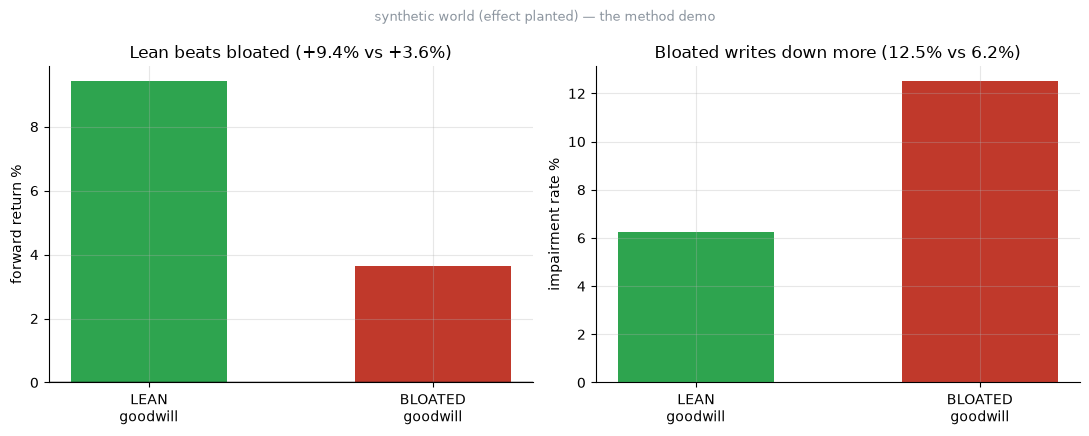

return: lean +9.4% vs bloated +3.6% (spread +5.8%)
impair: lean 6.2% vs bloated 12.5% (gap +6.2pp)


In [2]:
b = st.bucket_returns(PANEL, frac=0.2)
low_m, high_m = b['low_mean']*100, b['high_mean']*100
low_i, high_i = b['low_imp_rate']*100, b['high_imp_rate']*100
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
ax1.bar(['LEAN\ngoodwill','BLOATED\ngoodwill'], [low_m, high_m], color=[GREEN, RED], width=.55)
ax1.axhline(0, c='k', lw=1); ax1.set_ylabel('forward return %')
ax1.set_title(f'Lean beats bloated (+{low_m:.1f}% vs +{high_m:.1f}%)')
ax2.bar(['LEAN\ngoodwill','BLOATED\ngoodwill'], [low_i, high_i], color=[GREEN, RED], width=.55)
ax2.set_ylabel('impairment rate %')
ax2.set_title(f'Bloated writes down more ({high_i:.1f}% vs {low_i:.1f}%)')
fig.suptitle('synthetic world (effect planted) — the method demo', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'return: lean +{low_m:.1f}% vs bloated +{high_m:.1f}% (spread +{low_m-high_m:.1f}%)')
print(f'impair: lean {low_i:.1f}% vs bloated {high_i:.1f}% (gap +{high_i-low_i:.1f}pp)')

Both legs of the story show up **in the model**: the bloated fifth wrote down about twice as often (**12.5%** vs **6.2%**) and earned **5.78pp** less. That's exactly what the overpaid-acquisition idea predicts — *because we planted it*. The real question is whether the method is honest, which is beat 7.

**Does the pattern hold if we slice the buckets differently?** (deciles, quintiles, quartiles, thirds)

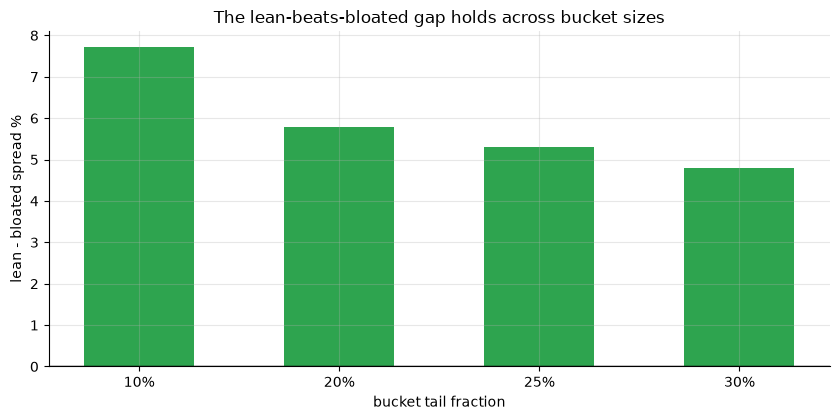

spreads by bucket fraction: [7.7, 5.8, 5.3, 4.8]


In [3]:
sweep = [(0.1, 7.71), (0.2, 5.78), (0.25, 5.3), (0.3, 4.79)]
fracs = [s[0] for s in sweep]
spreads = [st.bucket_returns(PANEL, f)['spread']*100 for f in fracs]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([f'{int(f*100)}%' for f in fracs], spreads, color=GREEN, width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('lean - bloated spread %')
ax.set_xlabel('bucket tail fraction')
ax.set_title('The lean-beats-bloated gap holds across bucket sizes')
plt.tight_layout(); plt.show()
print('spreads by bucket fraction:', [round(s,1) for s in spreads])

The gap stays positive whether we use the top/bottom 10% or 30% — the sign is stable *on this world*. (Whether it'd be stable on the **real** market is exactly what we can't check.)

## 5 · The verdict

- **Signal — Weak.** The idea is coherent and literature-backed, and the engine catches it cleanly *when it's planted*. But there's **no real tape** — so it can't earn `REAL`, only `WEAK`.
- **Tradability — Mirage.** No real result means nothing to trade; and the bloated-goodwill names you'd short are exactly the illiquid, corporate-action-prone ones.

## 6 · Could you actually trade it?

Not from here. Even if the effect is real on the full market, the trade means **shorting** the most goodwill-bloated firms — often smaller, recently-merged names that are expensive to borrow and prone to corporate actions. And we have no real data to size, cost, or confirm any of it. A method that *works in simulation* is a starting point, not a signal.

## 7 · Going further 🚪

- **The honest test needs real accounting data.** Point-in-time goodwill/assets at each year-end, plus tagged impairment events, for a survivorship-free universe — Compustat-grade data. Re-run the sort there and see if the lean-minus-bloated spread clears *t* = 2.
- **Cousins on the bench.** The accruals anomalies ([231](../../231-sloan-accruals/), [522](../../522-percent-operating-accruals/)) and the [distress-risk puzzle](../../540-distress-risk-anomaly/) test related balance-sheet flags.

*Think you can get the data? Fork this, drop in a real point-in-time goodwill/impairment panel, and show the spread clearing t = 2 the right way.*